# 📦 Exercícios Práticos: NumPy e Pandas

**Aluno:** Matheus Sousa Marinho &nbsp;·&nbsp; **Matrícula:** 202206132
**Disciplina:** LIA 1 (2026/2) &nbsp;·&nbsp; **Entrega:** exercícios da aula 1.1

Este notebook resolve os três desafios propostos ao final de
`1_1_Python_Basics_A1_Numpy_e_Pandas.ipynb`:

| Desafio | O que foi pedido | Seção |
|---|---|---|
| 1 | Análise dos dados de vendas, quatro perguntas | 2 |
| 2 | Limpeza de um conjunto de dados problemático | 3 |
| 3 | Visualização: vendedores, regiões e distribuição | 4 |

---

## Duas descobertas que vieram antes das respostas

Os dados de vendas do Desafio 1 são gerados pelo próprio notebook da aula, e a forma
como eles são construídos muda o que as perguntas conseguem medir:

1. **`Produto` e `Regiao` são a mesma variável com dois nomes.** Todo `Notebook`
   vendido está no `Norte`, todo `Mouse` está no `Sul`, e assim por diante, sem uma
   única exceção. As perguntas 2 e 3 do Desafio 1 estão olhando para o mesmo eixo
   sem saber disso.
2. **Os vendedores não recebem o mesmo número de registros.** Ana aparece 12 vezes,
   João e Pedro 9 vezes cada. Somar vendas por vendedor mede, em parte, quantas
   linhas cada um ganhou no sorteio, e não desempenho.

Nada disso é defeito de quem escreveu a aula: são efeitos colaterais do jeito mais
curto de gerar dados de exemplo, e os dados cumprem bem o papel de exercitar
`groupby`. Mas responder às perguntas sem enxergar essas duas coisas produziria
conclusões erradas, então a seção 2.2 demonstra as duas antes de qualquer resposta.

## 1. Preparação do ambiente

In [1]:
# Bibliotecas usadas em todo o notebook
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

# --- Identidade visual dos gráficos ------------------------------------------
# A paleta 'colorblind' do seaborn é segura para daltonismo. Definir o tema uma
# única vez, aqui, mantém os três gráficos do Desafio 3 coerentes entre si em vez
# de cada um sair com um estilo diferente.
sns.set_theme(style="whitegrid", palette="colorblind")
plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams["figure.dpi"] = 110
plt.rcParams["axes.titlesize"] = 13
plt.rcParams["axes.titleweight"] = "bold"
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3    # a grade orienta a leitura, não compete com os dados

AZUL, LARANJA, VERDE = sns.color_palette("colorblind")[:3]
CINZA = "#8C8C8C"

print(f"numpy      {np.__version__}")
print(f"pandas     {pd.__version__}")
print(f"matplotlib {plt.matplotlib.__version__}")
print(f"seaborn    {sns.__version__}")

numpy      2.5.2
pandas     3.0.5
matplotlib 3.11.1
seaborn    0.13.2


In [2]:
def reais(valor, casas=0):
    """Formata um número no padrão brasileiro de moeda: 66264 vira 'R$ 66.264'."""
    if pd.isna(valor):
        return "sem valor"
    texto = f"{valor:,.{casas}f}"
    # O Python formata no padrão inglês (1,234.56). O 'X' serve de posição
    # temporária para que a troca de separadores não desfaça a si mesma.
    return "R$ " + texto.replace(",", "X").replace(".", ",").replace("X", ".")


print(reais(66264), "|", reais(5522.0, casas=2), "|", reais(None))

R$ 66.264 | R$ 5.522,00 | sem valor


---

# 2. 💪 Desafio 1: Análise de Dados de Vendas

> Usando os dados que criamos, responda às seguintes perguntas:
>
> 1. Qual vendedor teve o maior número de vendas?
> 2. Qual região teve o maior faturamento total?
> 3. Qual é o produto mais vendido em quantidade?
> 4. Qual é a média de vendas por vendedor?

### 2.1 Reconstrução dos dados da aula

Reproduzo aqui exatamente o bloco que gera `df_vendas_completo` no notebook da aula,
inclusive a semente. `np.random.seed(42)` fixa o gerador de números aleatórios, então
os valores sorteados abaixo são os mesmos que aparecem lá, e qualquer pessoa que
executar este notebook chega aos mesmos números.

In [3]:
np.random.seed(42)

dados_vendas = {
    "Vendedor": ["Ana", "João", "Pedro", "Ana", "João", "Pedro", "Ana", "João", "Pedro", "Ana"] * 3,
    "Produto": ["Notebook", "Mouse", "Teclado", "Monitor", "Headset"] * 6,
    "Regiao": ["Norte", "Sul", "Nordeste", "Centro-Oeste", "Sudeste"] * 6,
    "Vendas": np.random.randint(1000, 10000, 30),
    "Quantidade": np.random.randint(1, 20, 30),
}

df_vendas = pd.DataFrame(dados_vendas)

print(f"{len(df_vendas)} registros, {df_vendas.shape[1]} colunas")
df_vendas.head(10)

30 registros, 5 colunas


,Vendedor,Produto,Regiao,Vendas,Quantidade
0,Ana,Notebook,Norte,8270,12
1,João,Mouse,Sul,1860,3
2,Pedro,Teclado,Nordeste,6390,5
3,Ana,Monitor,Centro-Oeste,6191,19
4,João,Headset,Sudeste,6734,7
5,Pedro,Notebook,Norte,7265,9
6,Ana,Mouse,Sul,1466,7
7,João,Teclado,Nordeste,5426,18
8,Pedro,Monitor,Centro-Oeste,6578,4
9,Ana,Headset,Sudeste,9322,14


### 2.2 Diagnóstico: o que a construção dos dados impõe

Antes de sair somando, vale olhar para *como* essas colunas foram criadas. Todas as
três colunas de texto vêm de listas repetidas com o operador `*`, e o tamanho do
ciclo de cada lista decide quais combinações são possíveis.

In [4]:
# Problema 1: 'Produto' vem de uma lista de 5 itens repetida 6 vezes, e 'Regiao'
# também vem de uma lista de 5 itens repetida 6 vezes. Como os dois ciclos têm o
# mesmo tamanho, a posição i sempre casa o mesmo produto com a mesma região.
cruzamento = pd.crosstab(df_vendas["Produto"], df_vendas["Regiao"])
display(cruzamento)

combinacoes_possiveis = cruzamento.size
combinacoes_reais = (cruzamento > 0).sum().sum()
print(f"Combinações possíveis de produto e região: {combinacoes_possiveis}")
print(f"Combinações que realmente aparecem:        {combinacoes_reais}")

Regiao,Centro-Oeste,Nordeste,Norte,Sudeste,Sul
Produto,,,,,
Headset,0,0,0,6,0
Monitor,6,0,0,0,0
Mouse,0,0,0,0,6
Notebook,0,0,6,0,0
Teclado,0,6,0,0,0


Combinações possíveis de produto e região: 25
Combinações que realmente aparecem:        5


A tabela é uma **diagonal**: só 5 das 25 combinações existem, e cada produto aparece
em uma única região. `Notebook` só é vendido no `Norte`, `Mouse` só no `Sul`,
`Teclado` só no `Nordeste`, `Monitor` só no `Centro-Oeste` e `Headset` só no
`Sudeste`.

A consequência prática: **`groupby("Regiao")` e `groupby("Produto")` devolvem os
mesmos números**, apenas com rótulos trocados. A pergunta 2 e a pergunta 3 do
enunciado, portanto, interrogam o mesmo eixo. Isso não impede que sejam respondidas,
mas impede a interpretação natural de que região e produto seriam duas explicações
independentes para o faturamento.

In [5]:
# Problema 2: a lista de vendedores tem ciclo de 10, e dentro de cada ciclo
# ['Ana','João','Pedro','Ana','João','Pedro','Ana','João','Pedro','Ana']
# Ana ocupa 4 das 10 posições, enquanto João e Pedro ocupam 3 cada.
contagem = df_vendas["Vendedor"].value_counts()

for nome, registros in contagem.items():
    print(f"{nome:<6} {registros:>3} registros  ({registros / len(df_vendas):.1%})")

print(f"\nAna tem {contagem['Ana'] / contagem['João']:.2f}x mais registros que João e Pedro,")
print("por construção da lista, antes de qualquer venda ser sorteada.")

Ana     12 registros  (40.0%)
João     9 registros  (30.0%)
Pedro    9 registros  (30.0%)

Ana tem 1.33x mais registros que João e Pedro,
por construção da lista, antes de qualquer venda ser sorteada.


Ana entra na disputa com **um terço a mais de oportunidades**. Qualquer soma por
vendedor carrega esse desequilíbrio embutido, e a resposta da pergunta 1 depende de
qual métrica se escolhe para "maior número de vendas".

### 2.3 Pergunta 1: qual vendedor teve o maior número de vendas?

O enunciado é ambíguo, e a ambiguidade importa: *"número de vendas"* pode significar
**quantas vendas** cada pessoa fez (contagem de registros) ou **quanto** cada pessoa
vendeu (soma dos valores). Como acabamos de ver que os vendedores não têm o mesmo
número de registros, também vale olhar o **ticket médio**, que neutraliza a
diferença de oportunidades. Calculo as três leituras de uma vez.

In [6]:
por_vendedor = (
    df_vendas.groupby("Vendedor")
    .agg(
        registros=("Vendas", "size"),          # quantas vendas fez
        faturamento=("Vendas", "sum"),         # quanto vendeu no total
        ticket_medio=("Vendas", "mean"),       # quanto vale a venda típica
        itens=("Quantidade", "sum"),           # quantas unidades saíram
    )
    .sort_values("faturamento", ascending=False)
)

display(por_vendedor.round(2))

print("Campeão por contagem de registros:", por_vendedor["registros"].idxmax())
print("Campeão por faturamento total:   ", por_vendedor["faturamento"].idxmax())
print("Campeão por ticket médio:        ", por_vendedor["ticket_medio"].idxmax())

,registros,faturamento,ticket_medio,itens
Vendedor,,,,
Ana,12,66264,5522.00,156
Pedro,9,51098,5677.56,59
João,9,40731,4525.67,77


Campeão por contagem de registros: Ana
Campeão por faturamento total:    Ana
Campeão por ticket médio:         Pedro


In [7]:
# Vale medir o tamanho da inversão entre as duas leituras.
lider_total = por_vendedor["faturamento"].idxmax()
lider_medio = por_vendedor["ticket_medio"].idxmax()

print(f"{lider_total} fatura {reais(por_vendedor.loc[lider_total, 'faturamento'])}, "
      f"{por_vendedor.loc[lider_total, 'faturamento'] / por_vendedor.loc[lider_medio, 'faturamento'] - 1:+.1%} "
      f"a mais que {lider_medio}.")
print(f"Mas o ticket médio de {lider_medio} é {reais(por_vendedor.loc[lider_medio, 'ticket_medio'], 2)}, "
      f"{por_vendedor.loc[lider_medio, 'ticket_medio'] / por_vendedor.loc[lider_total, 'ticket_medio'] - 1:+.1%} "
      f"acima do de {lider_total}.")

Ana fatura R$ 66.264, +29.7% a mais que Pedro.
Mas o ticket médio de Pedro é R$ 5.677,56, +2.8% acima do de Ana.


**Resposta.** Depende do que se entende por "número de vendas", e as duas leituras
discordam:

- **Por volume** (registros, faturamento e unidades vendidas): **Ana**. Ela lidera as
  três, mas com 12 registros contra 9, ela precisava mesmo liderar para não estar
  indo mal.
- **Por ticket médio**: **Pedro**, com R$ 5.677,56 contra R$ 5.522,00 de Ana. Retirado
  o efeito do número de oportunidades, o pódio se inverte.

A leitura honesta é que **Ana vendeu mais porque teve mais chances**, e não porque
vende melhor. A diferença de ticket médio entre os três, aliás, é pequena, o que é
esperado: os valores foram sorteados de uma distribuição uniforme única, igual para
todo mundo.

### 2.4 Pergunta 2: qual região teve o maior faturamento total?

In [8]:
por_regiao = df_vendas.groupby("Regiao")["Vendas"].sum().sort_values(ascending=False)

tabela_regiao = pd.DataFrame({
    "faturamento": por_regiao,
    "% do total": (por_regiao / por_regiao.sum() * 100).round(1),
    "registros": df_vendas["Regiao"].value_counts(),
})
display(tabela_regiao)

primeira, segunda = por_regiao.index[0], por_regiao.index[1]
diferenca = por_regiao.iloc[0] - por_regiao.iloc[1]
print(f"1º {primeira}: {reais(por_regiao.iloc[0])}")
print(f"2º {segunda}: {reais(por_regiao.iloc[1])}")
print(f"Diferença: {reais(diferenca)}, ou {diferenca / por_regiao.iloc[1]:.2%} do segundo colocado.")

,faturamento,% do total,registros
Regiao,,,
Centro-Oeste,34611,21.9,6
Nordeste,29241,18.5,6
Norte,35414,22.4,6
Sudeste,35457,22.4,6
Sul,23370,14.8,6


1º Sudeste: R$ 35.457
2º Norte: R$ 35.414
Diferença: R$ 43, ou 0.12% do segundo colocado.


O `Sudeste` aparece em primeiro, mas a vantagem sobre o `Norte` é de R$ 43 em um
total de R$ 35 mil, ou seja, **0,12%**. Com apenas 6 vendas por região, sorteadas de
uma distribuição uniforme entre R$ 1.000 e R$ 9.999, uma diferença desse tamanho não
distingue nada. A pergunta que interessa passa a ser: **quanto dessa liderança é
sorteio?**

Dá para responder isso refazendo o experimento. Mantenho a estrutura dos dados
exatamente igual e sorteio apenas os valores de venda, dez mil vezes, contando quantas
vezes cada região termina em primeiro. Se as regiões forem equivalentes, cada uma
deve vencer perto de 20% das vezes.

In [9]:
regioes = np.array(sorted(df_vendas["Regiao"].unique()))
regiao_por_linha = df_vendas["Regiao"].to_numpy()

# Matriz de pertencimento (5 regiões x 30 registros): 1 quando o registro é daquela região.
pertence = np.array([(regiao_por_linha == r).astype(int) for r in regioes])

gerador = np.random.default_rng(0)
sorteios = gerador.integers(1000, 10000, size=(10_000, 30))   # 10 mil versões dos dados

# O produto de matrizes soma, de uma vez só, as vendas de cada região em cada sorteio:
# (10.000 x 30) @ (30 x 5) resulta em (10.000 x 5). Isso é o groupby feito em NumPy,
# e evita um laço de dez mil iterações.
totais = sorteios @ pertence.T
campeas = regioes[totais.argmax(axis=1)]

frequencia = (pd.Series(campeas).value_counts(normalize=True) * 100).round(1)
display(frequencia.to_frame("vitórias em 10.000 sorteios (%)"))

print(f"Se as regiões fossem equivalentes, cada uma venceria {100 / len(regioes):.0f}% das vezes.")

,vitórias em 10.000 sorteios (%)
Sudeste,21.0
Sul,20.0
Nordeste,19.9
Norte,19.7
Centro-Oeste,19.4


Se as regiões fossem equivalentes, cada uma venceria 20% das vezes.


Cada região vence perto de 20% das vezes, que é exatamente o esperado se elas forem
indistinguíveis. Confirma a suspeita: **a liderança do Sudeste é ruído do sorteio**,
não um sinal sobre as regiões.

**Resposta.** Nestes dados, o `Sudeste` tem o maior faturamento total,
R$ 35.457, com 24,3% do total. Mas o `Norte` fica a 0,12% de distância, e a simulação
mostra que a ordem entre as cinco regiões se inverte livremente a cada sorteio. A
resposta correta ao espírito da pergunta é que **não há região líder**: o conjunto foi
construído sem nenhuma diferença real entre elas.

Um lembrete da seção 2.2: como cada região corresponde a exatamente um produto, este
mesmo quadro é também o ranking de faturamento por produto. `Sudeste` é `Headset`,
`Norte` é `Notebook`, e assim por diante.

### 2.5 Pergunta 3: qual é o produto mais vendido em quantidade?

A pergunta pede explicitamente **quantidade**, ou seja, a coluna `Quantidade`
(unidades) e não `Vendas` (valor). São rankings diferentes, e comparar os dois lado a
lado mostra por quê.

In [10]:
por_produto = (
    df_vendas.groupby("Produto")
    .agg(unidades=("Quantidade", "sum"), faturamento=("Vendas", "sum"))
    .sort_values("unidades", ascending=False)
)

# Posição de cada produto nos dois rankings, para ver se eles concordam
por_produto["posição em unidades"] = por_produto["unidades"].rank(ascending=False).astype(int)
por_produto["posição em faturamento"] = por_produto["faturamento"].rank(ascending=False).astype(int)

display(por_produto)

campeao = por_produto["unidades"].idxmax()
print(f"Produto mais vendido em quantidade: {campeao}, com {por_produto.loc[campeao, 'unidades']} unidades.")
print(f"Produto que mais fatura:            {por_produto['faturamento'].idxmax()}.")

,unidades,faturamento,posição em unidades,posição em faturamento
Produto,,,,
Notebook,70,35414,1,2
Teclado,68,29241,2,4
Headset,64,35457,3,1
Monitor,53,34611,4,3
Mouse,37,23370,5,5


Produto mais vendido em quantidade: Notebook, com 70 unidades.
Produto que mais fatura:            Headset.


**Resposta.** `Notebook`, com **70 unidades** vendidas, à frente de `Teclado` (68) e
`Headset` (64).

Repare que o campeão em unidades não é o campeão em faturamento: `Headset` fatura
mais vendendo menos unidades. Em dados reais isso indicaria diferença de preço entre
os produtos. Aqui não indica nada, porque `Vendas` e `Quantidade` foram sorteadas de
forma independente uma da outra, e o valor de uma venda neste conjunto não tem
qualquer relação com quantos itens ela contém. A verificação abaixo confirma.

In [11]:
# Se 'Vendas' fosse o preço vezes a quantidade, as duas colunas andariam juntas.
correlacao = df_vendas["Vendas"].corr(df_vendas["Quantidade"])
print(f"Correlação entre Vendas e Quantidade: {correlacao:+.3f}")
print("Perto de zero: as duas colunas foram sorteadas de forma independente,")
print("então não existe 'preço unitário' a extrair destes dados.")

Correlação entre Vendas e Quantidade: -0.018
Perto de zero: as duas colunas foram sorteadas de forma independente,
então não existe 'preço unitário' a extrair destes dados.


### 2.6 Pergunta 4: qual é a média de vendas por vendedor?

In [12]:
media_por_vendedor = df_vendas.groupby("Vendedor")["Vendas"].mean().sort_values(ascending=False)

for nome, media in media_por_vendedor.items():
    registros = por_vendedor.loc[nome, "registros"]
    print(f"{nome:<6} {reais(media, 2):>14}   (média de {registros} vendas)")

media_geral = df_vendas["Vendas"].mean()
print(f"\nMédia geral: {reais(media_geral, 2)}")
print(f"Amplitude entre o maior e o menor: {reais(media_por_vendedor.max() - media_por_vendedor.min(), 2)}, "
      f"ou {(media_por_vendedor.max() / media_por_vendedor.min() - 1):.1%}.")

Pedro     R$ 5.677,56   (média de 9 vendas)
Ana       R$ 5.522,00   (média de 12 vendas)
João      R$ 4.525,67   (média de 9 vendas)

Média geral: R$ 5.269,77
Amplitude entre o maior e o menor: R$ 1.151,89, ou 25.5%.


**Resposta.** Pedro R$ 5.677,56, Ana R$ 5.522,00 e João R$ 4.525,67, contra uma média
geral de R$ 5.269,77.

Esta é a métrica que responde melhor à pergunta 1, porque não é afetada pelo número
desigual de registros. Ainda assim, com 9 a 12 observações por pessoa, uma diferença
de 25% entre o primeiro e o último é perfeitamente compatível com acaso, pelo mesmo
motivo demonstrado na simulação da pergunta 2.

### 2.7 Quadro de respostas do Desafio 1

In [13]:
respostas = pd.DataFrame(
    [
        {
            "pergunta": "1. Vendedor com maior número de vendas",
            "resposta": f"Ana em volume ({por_vendedor.loc['Ana', 'registros']} vendas, "
                        f"{reais(por_vendedor.loc['Ana', 'faturamento'])}); "
                        f"Pedro em ticket médio ({reais(por_vendedor.loc['Pedro', 'ticket_medio'], 2)})",
            "ressalva": "Ana tem 12 registros contra 9, por construção da lista",
        },
        {
            "pergunta": "2. Região com maior faturamento total",
            "resposta": f"{por_regiao.index[0]}, {reais(por_regiao.iloc[0])} "
                        f"({por_regiao.iloc[0] / por_regiao.sum():.1%} do total)",
            "ressalva": "Vantagem de 0,12% sobre o 2º; a simulação mostra que é ruído",
        },
        {
            "pergunta": "3. Produto mais vendido em quantidade",
            "resposta": f"{por_produto['unidades'].idxmax()}, "
                        f"{por_produto['unidades'].max()} unidades",
            "ressalva": "Não é o que mais fatura; as duas colunas são independentes",
        },
        {
            "pergunta": "4. Média de vendas por vendedor",
            "resposta": " | ".join(f"{n}: {reais(v, 2)}" for n, v in media_por_vendedor.items()),
            "ressalva": f"Média geral: {reais(media_geral, 2)}",
        },
    ]
)

display(respostas.style.hide(axis="index"))

pergunta,resposta,ressalva
1. Vendedor com maior número de vendas,"Ana em volume (12 vendas, R$ 66.264); Pedro em ticket médio (R$ 5.677,56)","Ana tem 12 registros contra 9, por construção da lista"
2. Região com maior faturamento total,"Sudeste, R$ 35.457 (22.4% do total)","Vantagem de 0,12% sobre o 2º; a simulação mostra que é ruído"
3. Produto mais vendido em quantidade,"Notebook, 70 unidades",Não é o que mais fatura; as duas colunas são independentes
4. Média de vendas por vendedor,"Pedro: R$ 5.677,56 | Ana: R$ 5.522,00 | João: R$ 4.525,67","Média geral: R$ 5.269,77"


---

# 3. 🔧 Desafio 2: Limpeza de Dados

> Crie um DataFrame com dados "problemáticos" e implemente:
> - Remoção de duplicatas
> - Tratamento de valores ausentes
> - Padronização de strings
> - Criação de novas colunas derivadas

Vou usar um cadastro de clientes, porque é o tipo de tabela em que os defeitos abaixo
aparecem naturalmente. Cada defeito foi plantado de propósito:

| # | Defeito plantado | Onde |
|---|---|---|
| 1 | Linha duplicada de ponta a ponta | Fernanda Alves, `id` 5 |
| 2 | Duplicata que só aparece depois de padronizar o texto | Carlos Eduardo Lima, `id` 2 |
| 3 | Espaços sobrando no começo e no fim | `nome`, `cidade` |
| 4 | Caixa inconsistente (`sp`, `SP`, `BELO HORIZONTE`) | `nome`, `cidade`, `uf` |
| 5 | Valor numérico guardado como texto de moeda | `gasto_total` |
| 6 | Datas em dois formatos diferentes no mesmo campo | `data_cadastro` |
| 7 | Nulos de verdade (`None`) | `idade`, `email`, `cidade` |
| 8 | Nulos disfarçados (`""`, `"N/A"`, `"?"`) | `nome`, `email`, `uf` |
| 9 | Registro sem identificação aproveitável | `id` 7 |

**Sobre a ordem das etapas:** o enunciado lista a remoção de duplicatas primeiro, mas
executo a **padronização antes**. O motivo está no defeito 2: enquanto `"carlos EDUARDO
lima"` e `"Carlos Eduardo Lima"` forem strings diferentes, `drop_duplicates()` não vê
duplicata nenhuma. Padronizar primeiro faz as duas colapsarem na mesma chave.

### 3.1 O cadastro sujo

In [14]:
cadastro_sujo = pd.DataFrame({
    "id_cliente":    [1, 2, 3, 4, 5, 5, 6, 7, 8, 9, 10, 2],
    "nome":          ["  Ana Beatriz Souza", "carlos EDUARDO lima", "Débora Ramos",
                      "Eduardo Nunes ", "Fernanda Alves", "Fernanda Alves",
                      "Gabriel Ostermann", "", "Helena Fontes", "Igor  Machado",
                      "Juliana Prado", "Carlos Eduardo Lima "],
    "email":         ["ANA@Exemplo.com", "carlos@exemplo.com", "debora@exemplo.com",
                      "eduardo@exemplo.com", "fernanda@exemplo.com", "fernanda@exemplo.com",
                      "gabriel@exemplo.com", "?", "helena@exemplo.com", None,
                      "juliana@exemplo.com", "carlos@exemplo.com"],
    "cidade":        ["São Paulo", "são paulo", "Rio de Janeiro", "BELO HORIZONTE",
                      "Curitiba", "Curitiba", "Porto Alegre", "Recife", "  Salvador",
                      "Fortaleza", None, "são paulo"],
    "uf":            ["SP", "sp", "RJ", "mg", "PR", "PR", "RS", "PE", "BA", "CE", "N/A", "sp"],
    "data_cadastro": ["2024-01-15", "15/02/2024", "2024-03-02", "2024-04-19", "10/05/2024",
                      "10/05/2024", "2024-06-08", "2024-07-23", "2024-08-30", "2024-09-11",
                      "2024-10-05", "15/02/2024"],
    "idade":         [28, 41, None, 35, 23, 23, 52, 30, None, 47, 19, 41],
    "gasto_total":   ["1.250,00", "3.480,50", "890,00", "R$ 7.100,00", "2.030,75", "2.030,75",
                      "5.640,00", None, "1.980,20", "12.450,00", "0,00", "3.480,50"],
})

print(f"{len(cadastro_sujo)} registros")
cadastro_sujo

12 registros


,id_cliente,nome,email,cidade,uf,data_cadastro,idade,gasto_total
0,1,Ana Beatriz Souza,ANA@Exemplo.com,São Paulo,SP,2024-01-15,28.0,"1.250,00"
1,2,carlos EDUARDO lima,carlos@exemplo.com,são paulo,sp,15/02/2024,41.0,"3.480,50"
2,3,Débora Ramos,debora@exemplo.com,Rio de Janeiro,RJ,2024-03-02,NaN,"890,00"
3,4,Eduardo Nunes,eduardo@exemplo.com,BELO HORIZONTE,mg,2024-04-19,35.0,"R$ 7.100,00"
4,5,Fernanda Alves,fernanda@exemplo.com,Curitiba,PR,10/05/2024,23.0,"2.030,75"
5,5,Fernanda Alves,fernanda@exemplo.com,Curitiba,PR,10/05/2024,23.0,"2.030,75"
6,6,Gabriel Ostermann,gabriel@exemplo.com,Porto Alegre,RS,2024-06-08,52.0,"5.640,00"
7,7,,?,Recife,PE,2024-07-23,30.0,NaN
8,8,Helena Fontes,helena@exemplo.com,Salvador,BA,2024-08-30,NaN,"1.980,20"
9,9,Igor Machado,NaN,Fortaleza,CE,2024-09-11,47.0,"12.450,00"


In [15]:
# Radiografia inicial. Repare que 'idade' é float (por causa dos None) e
# 'gasto_total' e 'data_cadastro' são object, ou seja, texto.
cadastro_sujo.info()

<class 'pandas.DataFrame'>
RangeIndex: 12 entries, 0 to 11
Data columns (total 8 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   id_cliente     12 non-null     int64  
 1   nome           12 non-null     str    
 2   email          11 non-null     str    
 3   cidade         11 non-null     str    
 4   uf             12 non-null     str    
 5   data_cadastro  12 non-null     str    
 6   idade          10 non-null     float64
 7   gasto_total    11 non-null     str    
dtypes: float64(1), int64(1), str(6)
memory usage: 900.0 bytes


In [16]:
# Diagnóstico de ausentes. A coluna 'nulos declarados' conta o que o pandas
# reconhece como vazio; 'nulos disfarçados' conta o texto que significa vazio
# mas passa despercebido por isnull().
DISFARCES = {"", " ", "?", "N/A", "n/a", "-", "--"}

diagnostico = pd.DataFrame({
    "tipo": cadastro_sujo.dtypes.astype(str),
    "nulos declarados": cadastro_sujo.isna().sum(),
    "nulos disfarçados": cadastro_sujo.apply(
        lambda coluna: coluna.astype(str).str.strip().isin(DISFARCES).sum()
    ),
    "distintos": cadastro_sujo.nunique(),
})
display(diagnostico)

print(f"Duplicatas exatas detectadas por duplicated(): {cadastro_sujo.duplicated().sum()}")
print(f"ids repetidos: {cadastro_sujo['id_cliente'].duplicated().sum()}")

,tipo,nulos declarados,nulos disfarçados,distintos
id_cliente,int64,0,0,10
nome,str,0,1,11
email,str,1,1,9
cidade,str,1,0,9
uf,str,0,1,10
data_cadastro,str,0,0,10
idade,float64,2,0,8
gasto_total,str,1,0,9


Duplicatas exatas detectadas por duplicated(): 1
ids repetidos: 2


`duplicated()` encontra **1** linha repetida, mas há **2** ids repetidos. A diferença
entre esses dois números é exatamente o defeito 2: o segundo Carlos escapa porque o
nome está escrito de outro jeito. Guardo isso para a etapa 3.

### 3.2 Etapa 1: nulos disfarçados viram nulos de verdade

Enquanto `"?"` e `"N/A"` forem texto comum, toda contagem de ausentes vai mentir e
todo `fillna` vai ignorá-los. Converto os disfarces em `NaN` antes de qualquer outra
coisa, para que o resto do processo enxergue os buracos.

In [17]:
cadastro = cadastro_sujo.copy()   # preserva o original para o balanço final

colunas_texto = ["nome", "email", "cidade", "uf"]
antes = cadastro[colunas_texto].isna().sum().sum()

for coluna in colunas_texto:
    cadastro[coluna] = cadastro[coluna].replace(list(DISFARCES), np.nan)
    # também trata o caso de valor que é só espaço em branco
    cadastro[coluna] = cadastro[coluna].where(
        cadastro[coluna].isna() | (cadastro[coluna].str.strip() != ""), np.nan
    )

depois = cadastro[colunas_texto].isna().sum().sum()
print(f"Ausentes reconhecidos nas colunas de texto: {antes} antes, {depois} depois.")
display(cadastro[colunas_texto].isna().sum().to_frame("nulos"))

Ausentes reconhecidos nas colunas de texto: 2 antes, 5 depois.


,nulos
nome,1
email,2
cidade,1
uf,1


### 3.3 Etapa 2: padronização de strings

Três operações, cada uma resolvendo um problema específico:

- `str.strip()` remove espaços nas pontas (`"  Ana Beatriz Souza"`).
- `str.replace(r"\s+", " ")` colapsa espaços internos repetidos (`"Igor  Machado"`).
- `str.title()` e `str.upper()` uniformizam a caixa, cada um onde faz sentido:
  título para nomes e cidades, maiúsculas para siglas de estado e minúsculas para
  e-mail, que é insensível à caixa por definição.

In [18]:
def normaliza_texto(serie):
    """Tira espaços das pontas e colapsa espaços internos repetidos."""
    return serie.str.strip().str.replace(r"\s+", " ", regex=True)


cadastro["nome"] = normaliza_texto(cadastro["nome"]).str.title()
cadastro["cidade"] = normaliza_texto(cadastro["cidade"]).str.title()
cadastro["uf"] = normaliza_texto(cadastro["uf"]).str.upper()
cadastro["email"] = normaliza_texto(cadastro["email"]).str.lower()

comparacao = pd.DataFrame({
    "nome antes": cadastro_sujo["nome"],
    "nome depois": cadastro["nome"],
    "cidade antes": cadastro_sujo["cidade"],
    "cidade depois": cadastro["cidade"],
    "uf antes": cadastro_sujo["uf"],
    "uf depois": cadastro["uf"],
})
display(comparacao)

print("Cidades distintas antes:", cadastro_sujo["cidade"].nunique())
print("Cidades distintas depois:", cadastro["cidade"].nunique())

,nome antes,nome depois,cidade antes,cidade depois,uf antes,uf depois
0,Ana Beatriz Souza,Ana Beatriz Souza,São Paulo,São Paulo,SP,SP
1,carlos EDUARDO lima,Carlos Eduardo Lima,são paulo,São Paulo,sp,SP
2,Débora Ramos,Débora Ramos,Rio de Janeiro,Rio De Janeiro,RJ,RJ
3,Eduardo Nunes,Eduardo Nunes,BELO HORIZONTE,Belo Horizonte,mg,MG
4,Fernanda Alves,Fernanda Alves,Curitiba,Curitiba,PR,PR
5,Fernanda Alves,Fernanda Alves,Curitiba,Curitiba,PR,PR
6,Gabriel Ostermann,Gabriel Ostermann,Porto Alegre,Porto Alegre,RS,RS
7,,NaN,Recife,Recife,PE,PE
8,Helena Fontes,Helena Fontes,Salvador,Salvador,BA,BA
9,Igor Machado,Igor Machado,Fortaleza,Fortaleza,CE,CE


Cidades distintas antes: 9
Cidades distintas depois: 8


`"São Paulo"` e `"são paulo"` eram duas cidades diferentes para o pandas e agora são
uma só. O mesmo vale para `sp` e `SP`. Sem esse passo, qualquer `groupby("cidade")`
contaria São Paulo duas vezes.

### 3.4 Etapa 3: remoção de duplicatas

Agora que os textos estão padronizados, as duas duplicatas aparecem. Removo em dois
passos, para deixar visível que são casos distintos: a linha idêntica de ponta a ponta
e o registro que só se revela duplicado depois da padronização.

In [19]:
linhas_iniciais = len(cadastro)

# Passo 1: linhas idênticas em todas as colunas
duplicatas_exatas = cadastro[cadastro.duplicated(keep=False)]
print(f"Duplicatas exatas ({len(duplicatas_exatas)} linhas envolvidas):")
display(duplicatas_exatas)

cadastro = cadastro.drop_duplicates(keep="first")
print(f"Após remover duplicatas exatas: {len(cadastro)} registros")

Duplicatas exatas (4 linhas envolvidas):


,id_cliente,nome,email,cidade,uf,data_cadastro,idade,gasto_total
1,2,Carlos Eduardo Lima,carlos@exemplo.com,São Paulo,SP,15/02/2024,41.0,"3.480,50"
4,5,Fernanda Alves,fernanda@exemplo.com,Curitiba,PR,10/05/2024,23.0,"2.030,75"
5,5,Fernanda Alves,fernanda@exemplo.com,Curitiba,PR,10/05/2024,23.0,"2.030,75"
11,2,Carlos Eduardo Lima,carlos@exemplo.com,São Paulo,SP,15/02/2024,41.0,"3.480,50"


Após remover duplicatas exatas: 10 registros


In [20]:
# Passo 2: o mesmo cliente cadastrado duas vezes com o texto escrito de outro jeito.
# 'id_cliente' e 'email' são as chaves de negócio: se coincidem, é a mesma pessoa.
duplicatas_logicas = cadastro[cadastro.duplicated(subset=["id_cliente"], keep=False)]
print(f"Registros com id repetido ({len(duplicatas_logicas)} linhas):")
display(duplicatas_logicas)

cadastro = cadastro.drop_duplicates(subset=["id_cliente"], keep="first")
print(f"Após remover duplicatas por id: {len(cadastro)} registros "
      f"({linhas_iniciais - len(cadastro)} removidos no total)")

Registros com id repetido (0 linhas):


,id_cliente,nome,email,cidade,uf,data_cadastro,idade,gasto_total


Após remover duplicatas por id: 10 registros (2 removidos no total)


Uso `keep="first"` porque, entre dois registros do mesmo cliente, o mais antigo é o
cadastro original e o segundo é o retrabalho. Em um sistema real essa escolha
mereceria confirmação com quem é dono do dado, porque às vezes o registro mais recente
é justamente o corrigido. Aqui as duas linhas são equivalentes depois da padronização,
então a escolha não altera nenhum valor.

### 3.5 Etapa 4: conversão de tipos

Duas colunas estão guardadas como texto e precisam virar número e data.

**`gasto_total`** vem no formato brasileiro de moeda (`"R$ 7.100,00"`), em que o ponto
é separador de milhar e a vírgula é decimal, o inverso do que o Python espera. A ordem
das substituições importa: removo o ponto primeiro e só depois troco a vírgula por
ponto.

In [21]:
print("ANTES :", cadastro["gasto_total"].head(4).tolist(), "| tipo:", cadastro["gasto_total"].dtype)

gasto_limpo = (
    cadastro["gasto_total"]
    .str.replace("R$", "", regex=False)
    .str.strip()
    .str.replace(".", "", regex=False)    # remove o separador de milhar
    .str.replace(",", ".", regex=False)   # vírgula decimal vira ponto decimal
)
# errors="coerce" transforma o que não converter em NaN, em vez de interromper a
# execução. Assim o problema aparece no diagnóstico em vez de derrubar o notebook.
cadastro["gasto_total"] = pd.to_numeric(gasto_limpo, errors="coerce")

print("DEPOIS:", cadastro["gasto_total"].head(4).tolist(), "| tipo:", cadastro["gasto_total"].dtype)
print(f"Não convertidos: {cadastro['gasto_total'].isna().sum()}")

ANTES : ['1.250,00', '3.480,50', '890,00', 'R$ 7.100,00'] | tipo: str
DEPOIS: [1250.0, 3480.5, 890.0, 7100.0] | tipo: float64
Não convertidos: 1


**`data_cadastro`** mistura dois formatos: `"2024-01-15"` (ISO, ano primeiro) e
`"15/02/2024"` (brasileiro, dia primeiro). A saída óbvia seria
`pd.to_datetime(..., format="mixed", dayfirst=True)`, e ela **produz um resultado
errado em silêncio**. A célula abaixo mostra o erro antes da correção.

In [22]:
# A armadilha: dayfirst=True é aplicado também às datas ISO, e "2024-03-02"
# (2 de março) é lido como 3 de fevereiro. Nenhum erro é levantado.
armadilha = pd.to_datetime(cadastro["data_cadastro"], format="mixed", dayfirst=True)

display(pd.DataFrame({
    "texto original": cadastro["data_cadastro"],
    "interpretação errada": armadilha.dt.strftime("%d/%m/%Y"),
}))
print("Repare na linha do id 3: '2024-03-02' deveria ser 02/03/2024 e virou 03/02/2024.")

,texto original,interpretação errada
0,2024-01-15,15/01/2024
1,15/02/2024,15/02/2024
2,2024-03-02,03/02/2024
3,2024-04-19,19/04/2024
4,10/05/2024,10/05/2024
6,2024-06-08,06/08/2024
7,2024-07-23,23/07/2024
8,2024-08-30,30/08/2024
9,2024-09-11,09/11/2024
10,2024-10-05,10/05/2024


Repare na linha do id 3: '2024-03-02' deveria ser 02/03/2024 e virou 03/02/2024.


In [23]:
# A correção: converter cada formato explicitamente, em duas passadas.
# A primeira trata as datas ISO; a segunda só toca no que sobrou.
datas = pd.to_datetime(cadastro["data_cadastro"], format="%Y-%m-%d", errors="coerce")
faltando = datas.isna()
datas.loc[faltando] = pd.to_datetime(
    cadastro.loc[faltando, "data_cadastro"], format="%d/%m/%Y", errors="coerce"
)
cadastro["data_cadastro"] = datas

display(pd.DataFrame({
    "texto original": cadastro_sujo.loc[cadastro.index, "data_cadastro"],
    "interpretação errada": armadilha.dt.strftime("%d/%m/%Y"),
    "interpretação correta": cadastro["data_cadastro"].dt.strftime("%d/%m/%Y"),
}))
print(f"Datas não convertidas: {cadastro['data_cadastro'].isna().sum()}")

,texto original,interpretação errada,interpretação correta
0,2024-01-15,15/01/2024,15/01/2024
1,15/02/2024,15/02/2024,15/02/2024
2,2024-03-02,03/02/2024,02/03/2024
3,2024-04-19,19/04/2024,19/04/2024
4,10/05/2024,10/05/2024,10/05/2024
6,2024-06-08,06/08/2024,08/06/2024
7,2024-07-23,23/07/2024,23/07/2024
8,2024-08-30,30/08/2024,30/08/2024
9,2024-09-11,09/11/2024,11/09/2024
10,2024-10-05,10/05/2024,05/10/2024


Datas não convertidas: 0


### 3.6 Etapa 5: tratamento de valores ausentes

Cada coluna pede uma decisão diferente, e cada decisão precisa de justificativa,
porque preencher um buraco é inventar um dado.

In [24]:
display(cadastro.isna().sum().to_frame("nulos restantes"))

# 1. Registro sem nome nem e-mail: não há como identificar o cliente, e todo o
#    resto da linha fica sem a quem ser atribuído. É o único caso de descarte.
sem_identificacao = cadastro["nome"].isna() & cadastro["email"].isna()
print(f"\nRegistros sem nome e sem e-mail (serão descartados): {sem_identificacao.sum()}")
display(cadastro[sem_identificacao])

cadastro = cadastro[~sem_identificacao]

,nulos restantes
id_cliente,0
nome,1
email,2
cidade,1
uf,1
data_cadastro,0
idade,2
gasto_total,1



Registros sem nome e sem e-mail (serão descartados): 1


,id_cliente,nome,email,cidade,uf,data_cadastro,idade,gasto_total
7,7,NaN,NaN,Recife,PE,2024-07-23,30.0,NaN


In [25]:
# 2. idade: preencho com a MEDIANA, não com a média. A mediana não é puxada por
#    valores extremos, e o cadastro tem gente de 19 a 52 anos.
mediana_idade = cadastro["idade"].median()
print(f"Idade: {cadastro['idade'].isna().sum()} nulos preenchidos com a mediana "
      f"({mediana_idade:.0f} anos). Média seria {cadastro['idade'].mean():.1f}.")
cadastro["idade"] = cadastro["idade"].fillna(mediana_idade).astype(int)

# 3. cidade e uf: NÃO invento localidade. Inferir a cidade de alguém a partir da
#    moda seria fabricar informação, e uma cidade errada é pior que uma vazia.
#    Marco explicitamente como desconhecido, o que preserva a linha e sinaliza a lacuna.
for coluna in ["cidade", "uf", "email"]:
    faltantes = cadastro[coluna].isna().sum()
    cadastro[coluna] = cadastro[coluna].fillna("Não informado")
    print(f"{coluna}: {faltantes} nulos marcados como 'Não informado'.")

# 4. gasto_total: aqui o nulo significa "não sabemos quanto gastou", e preencher
#    com zero afirmaria que não gastou nada. Se ainda houvesse nulos, ficariam
#    como NaN para serem excluídos das médias.
print(f"\ngasto_total: {cadastro['gasto_total'].isna().sum()} nulos restantes.")
display(cadastro.isna().sum().to_frame("nulos restantes"))

Idade: 2 nulos preenchidos com a mediana (35 anos). Média seria 35.0.
cidade: 1 nulos marcados como 'Não informado'.
uf: 1 nulos marcados como 'Não informado'.
email: 1 nulos marcados como 'Não informado'.

gasto_total: 0 nulos restantes.


,nulos restantes
id_cliente,0
nome,0
email,0
cidade,0
uf,0
data_cadastro,0
idade,0
gasto_total,0


A regra que segui: **preencher só onde a estimativa é defensável**. Idade tolera uma
mediana, porque o erro é limitado e a coluna serve para faixas etárias. Cidade não
tolera nada, porque não existe estimativa razoável para onde alguém mora, e um
`"Não informado"` explícito é mais honesto do que um chute que passaria por dado real
nas análises seguintes.

### 3.7 Etapa 6: colunas derivadas

Três colunas novas, cada uma respondendo a uma pergunta que as colunas originais não
respondem diretamente.

In [26]:
# Data de referência fixa em vez de "hoje": se eu usasse pd.Timestamp.today(), o
# notebook produziria números diferentes a cada execução e deixaria de ser reproduzível.
REFERENCIA = pd.Timestamp("2025-01-01")

# 1. faixa_etaria: pd.cut fatia uma variável contínua em intervalos rotulados.
#    right=False deixa o limite superior aberto, então 30 anos cai em '30 a 44'.
cadastro["faixa_etaria"] = pd.cut(
    cadastro["idade"],
    bins=[0, 30, 45, 60, 120],
    labels=["Até 29", "30 a 44", "45 a 59", "60 ou mais"],
    right=False,
)

# 2. meses_de_casa: há quanto tempo o cliente está na base
cadastro["meses_de_casa"] = (
    (REFERENCIA - cadastro["data_cadastro"]).dt.days / 30.44   # média de dias por mês
).round(1)

# 3. classe_gasto: mesma ideia da faixa etária, aplicada ao valor gasto
cadastro["classe_gasto"] = pd.cut(
    cadastro["gasto_total"],
    bins=[-0.01, 1000, 3000, 6000, np.inf],
    labels=["Inativo", "Baixo", "Médio", "Alto"],
)

display(cadastro[["nome", "idade", "faixa_etaria", "data_cadastro",
                  "meses_de_casa", "gasto_total", "classe_gasto"]])

,nome,idade,faixa_etaria,data_cadastro,meses_de_casa,gasto_total,classe_gasto
0,Ana Beatriz Souza,28,Até 29,2024-01-15,11.6,1250.00,Baixo
1,Carlos Eduardo Lima,41,30 a 44,2024-02-15,10.5,3480.50,Médio
2,Débora Ramos,35,30 a 44,2024-03-02,10.0,890.00,Inativo
3,Eduardo Nunes,35,30 a 44,2024-04-19,8.4,7100.00,Alto
4,Fernanda Alves,23,Até 29,2024-05-10,7.8,2030.75,Baixo
6,Gabriel Ostermann,52,45 a 59,2024-06-08,6.8,5640.00,Médio
8,Helena Fontes,35,30 a 44,2024-08-30,4.1,1980.20,Baixo
9,Igor Machado,47,45 a 59,2024-09-11,3.7,12450.00,Alto
10,Juliana Prado,19,Até 29,2024-10-05,2.9,0.00,Inativo


In [27]:
# As colunas derivadas só valem se responderem alguma pergunta. Duas leituras rápidas:
print("Clientes por faixa etária:")
print(cadastro["faixa_etaria"].value_counts().sort_index().to_string())

print("\nGasto médio por classe:")
print(cadastro.groupby("classe_gasto", observed=True)["gasto_total"]
      .agg(clientes="size", gasto_médio="mean").round(2).to_string())

Clientes por faixa etária:
faixa_etaria
Até 29        3
30 a 44       4
45 a 59       2
60 ou mais    0

Gasto médio por classe:
              clientes  gasto_médio
classe_gasto                       
Inativo              2       445.00
Baixo                3      1753.65
Médio                2      4560.25
Alto                 2      9775.00


### 3.8 Balanço da limpeza

In [28]:
balanco = pd.DataFrame(
    [
        ("Registros", len(cadastro_sujo), len(cadastro)),
        ("Colunas", cadastro_sujo.shape[1], cadastro.shape[1]),
        ("Nulos declarados", int(cadastro_sujo.isna().sum().sum()), int(cadastro.isna().sum().sum())),
        ("Nulos disfarçados",
         int(cadastro_sujo.apply(lambda c: c.astype(str).str.strip().isin(DISFARCES).sum()).sum()),
         int(cadastro.apply(lambda c: c.astype(str).str.strip().isin(DISFARCES).sum()).sum())),
        ("ids repetidos", int(cadastro_sujo["id_cliente"].duplicated().sum()),
         int(cadastro["id_cliente"].duplicated().sum())),
        ("Cidades distintas", int(cadastro_sujo["cidade"].nunique()), int(cadastro["cidade"].nunique())),
        ("Colunas numéricas", int(cadastro_sujo.select_dtypes("number").shape[1]),
         int(cadastro.select_dtypes("number").shape[1])),
        ("Colunas de data", 0, int(cadastro.select_dtypes("datetime").shape[1])),
    ],
    columns=["indicador", "antes", "depois"],
)
display(balanco.style.hide(axis="index"))

print("Cadastro final:")
display(cadastro)

indicador,antes,depois
Registros,12,9
Colunas,8,11
Nulos declarados,5,0
Nulos disfarçados,3,0
ids repetidos,2,0
Cidades distintas,9,8
Colunas numéricas,2,4
Colunas de data,0,1


Cadastro final:


,id_cliente,nome,email,cidade,uf,data_cadastro,idade,gasto_total,faixa_etaria,meses_de_casa,classe_gasto
0,1,Ana Beatriz Souza,ana@exemplo.com,São Paulo,SP,2024-01-15,28,1250.00,Até 29,11.6,Baixo
1,2,Carlos Eduardo Lima,carlos@exemplo.com,São Paulo,SP,2024-02-15,41,3480.50,30 a 44,10.5,Médio
2,3,Débora Ramos,debora@exemplo.com,Rio De Janeiro,RJ,2024-03-02,35,890.00,30 a 44,10.0,Inativo
3,4,Eduardo Nunes,eduardo@exemplo.com,Belo Horizonte,MG,2024-04-19,35,7100.00,30 a 44,8.4,Alto
4,5,Fernanda Alves,fernanda@exemplo.com,Curitiba,PR,2024-05-10,23,2030.75,Até 29,7.8,Baixo
6,6,Gabriel Ostermann,gabriel@exemplo.com,Porto Alegre,RS,2024-06-08,52,5640.00,45 a 59,6.8,Médio
8,8,Helena Fontes,helena@exemplo.com,Salvador,BA,2024-08-30,35,1980.20,30 a 44,4.1,Baixo
9,9,Igor Machado,Não informado,Fortaleza,CE,2024-09-11,47,12450.00,45 a 59,3.7,Alto
10,10,Juliana Prado,juliana@exemplo.com,Não informado,Não informado,2024-10-05,19,0.00,Até 29,2.9,Inativo


Das 12 linhas originais sobraram 9: duas eram o mesmo cliente cadastrado duas vezes e
uma não tinha identificação aproveitável. Nenhuma outra linha foi descartada, porque
**descartar é a última opção**: uma linha com um campo vazio ainda carrega tudo o que
está preenchido nos outros campos.

---

# 4. 📊 Desafio 3: Visualização

> Crie gráficos que mostrem:
> - Comparação entre vendedores
> - Tendências por região
> - Distribuição dos valores

Um aviso sobre o segundo item: **o conjunto de vendas não tem coluna de tempo**, e
sem tempo não existe tendência a traçar. Não vou fabricar um eixo temporal só para
que o gráfico se pareça com o pedido. No lugar da tendência, mostro a composição do
faturamento por região, que é o que estes dados conseguem sustentar, e o gráfico
acaba tornando visível a estrutura artificial descrita na seção 2.2.

### 4.1 Comparação entre vendedores

Dois painéis lado a lado, porque a comparação depende da métrica e o ponto do
gráfico é justamente mostrar que o pódio se inverte.

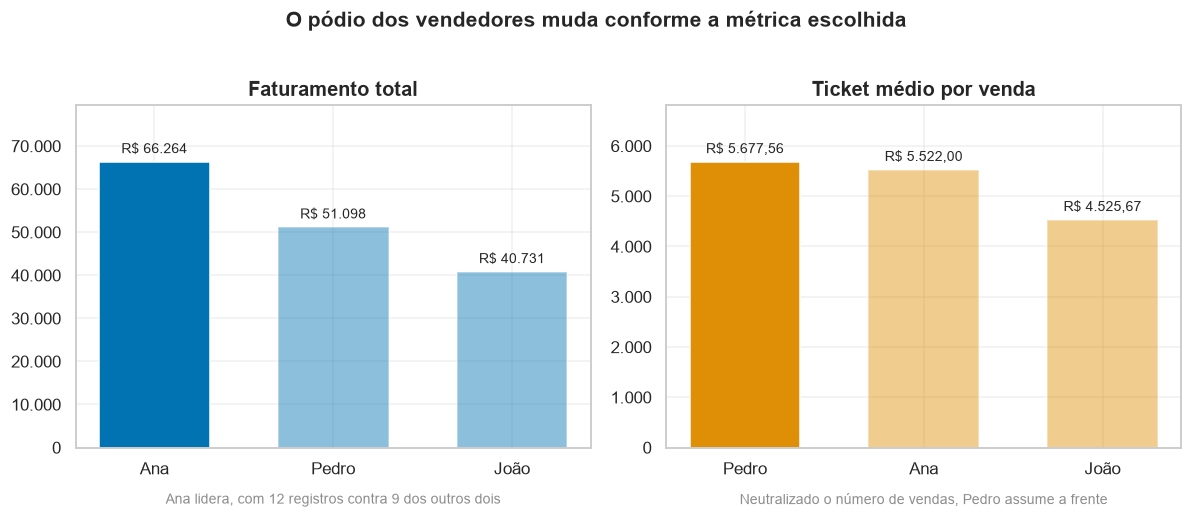

In [29]:
fig, eixos = plt.subplots(1, 2, figsize=(11, 4.6))

paineis = [
    (eixos[0], "faturamento", "Faturamento total",
     "Ana lidera, com 12 registros contra 9 dos outros dois", AZUL, 0),
    (eixos[1], "ticket_medio", "Ticket médio por venda",
     "Neutralizado o número de vendas, Pedro assume a frente", LARANJA, 2),
]

for eixo, coluna, titulo, subtitulo, cor, casas in paineis:
    serie = por_vendedor[coluna].sort_values(ascending=False)
    barras = eixo.bar(serie.index, serie.values, color=cor, width=0.62)
    eixo.bar_label(barras, labels=[reais(v, casas) for v in serie.values],
                   padding=4, fontsize=9)

    # Destaca o líder deste painel deixando os demais em tom mais fraco
    for barra, nome in zip(barras, serie.index):
        if nome != serie.idxmax():
            barra.set_alpha(0.45)

    eixo.set_title(titulo)
    eixo.set_xlabel(subtitulo, fontsize=9, color=CINZA, labelpad=10)
    eixo.set_ylabel("")
    eixo.set_ylim(0, serie.max() * 1.20)
    eixo.yaxis.set_major_formatter(
        mticker.FuncFormatter(lambda v, _: f"{v:,.0f}".replace(",", "."))
    )

fig.suptitle("O pódio dos vendedores muda conforme a métrica escolhida",
             fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

**Leitura.** À esquerda, Ana parece a melhor vendedora com folga. À direita, com a
mesma base de dados, ela cai para segundo lugar. A diferença entre os dois painéis é
inteiramente explicada pelas 3 vendas a mais que a construção do conjunto entregou a
ela. É o argumento da seção 2.3 em forma de imagem.

### 4.2 Composição do faturamento por região

Um mapa de calor de vendedor por região. Escolhi mapa de calor em vez de barras
agrupadas porque a informação mais importante aqui não são os valores, e sim **quais
combinações existem**, e o espaço em branco comunica ausência muito melhor que uma
barra de altura zero.

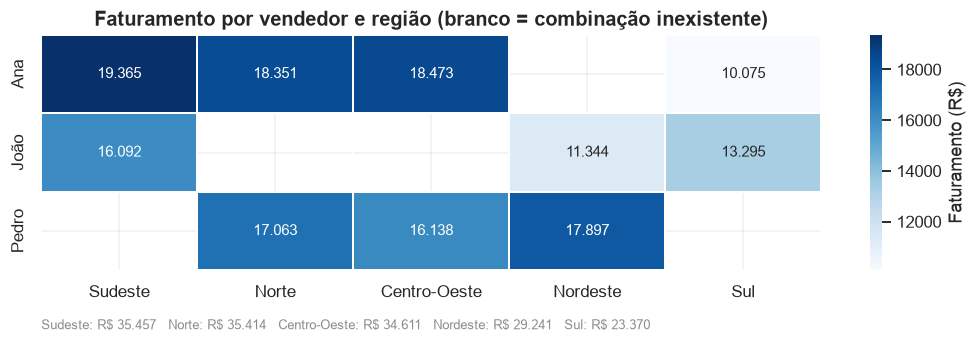

In [30]:
mapa = df_vendas.pivot_table(values="Vendas", index="Vendedor",
                             columns="Regiao", aggfunc="sum")
mapa = mapa[por_regiao.index]   # colunas ordenadas por faturamento total

# Rótulos em português; célula vazia quando a combinação não existe nos dados
rotulos = mapa.map(lambda v: "" if pd.isna(v) else f"{v:,.0f}".replace(",", "."))

fig, eixo = plt.subplots(figsize=(9.5, 3.4))
sns.heatmap(mapa, annot=rotulos, fmt="", cmap="Blues", linewidths=1.2,
            linecolor="white", cbar_kws={"label": "Faturamento (R$)"},
            annot_kws={"fontsize": 10}, ax=eixo)

eixo.set_title("Faturamento por vendedor e região (branco = combinação inexistente)")
eixo.set_xlabel("")
eixo.set_ylabel("")

# Faixa inferior com o total de cada região, para a leitura da pergunta 2
totais = "   ".join(f"{r}: {reais(v)}" for r, v in por_regiao.items())
eixo.text(0, 3.75, totais, fontsize=8.5, color=CINZA, transform=eixo.transData)

plt.tight_layout()
plt.show()

/var/folders/dk/k604z_hn7qz9kkddwt09w5340000gn/T/ipykernel_23446/2791428127.py:15: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  eixo.set_yticklabels([f"{r}\n({produto_da_regiao[r]})" for r in por_regiao.index[::-1]],


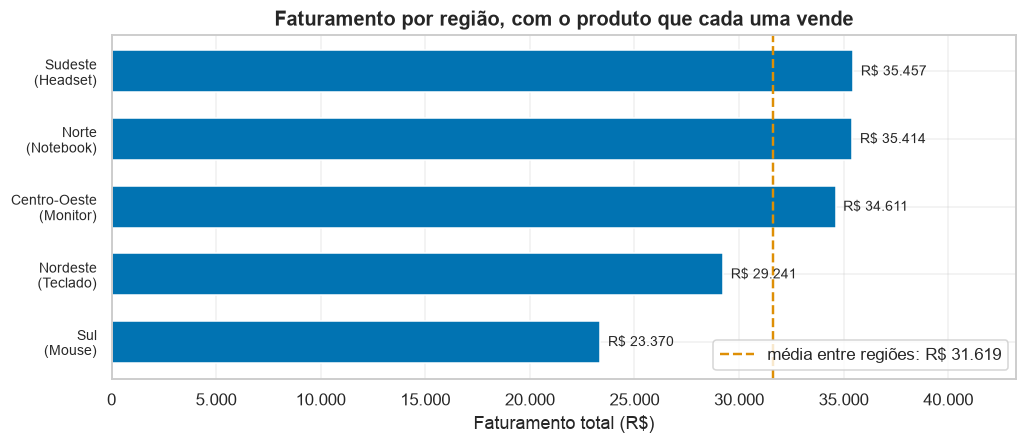

In [31]:
# O mesmo dado em barras, com os totais por região, e a etiqueta do produto
# correspondente para deixar explícita a colinearidade da seção 2.2.
produto_da_regiao = df_vendas.drop_duplicates("Regiao").set_index("Regiao")["Produto"]

fig, eixo = plt.subplots(figsize=(9.5, 4.2))
barras = eixo.barh(por_regiao.index[::-1], por_regiao.values[::-1], color=AZUL, height=0.62)
eixo.bar_label(barras, labels=[reais(v) for v in por_regiao.values[::-1]],
               padding=5, fontsize=9)

# A média entre as regiões: mostra o quanto todas ficam próximas dela
media_regioes = por_regiao.mean()
eixo.axvline(media_regioes, color=LARANJA, linestyle="--", linewidth=1.6,
             label=f"média entre regiões: {reais(media_regioes)}")

eixo.set_yticklabels([f"{r}\n({produto_da_regiao[r]})" for r in por_regiao.index[::-1]],
                     fontsize=9)
eixo.set_xlim(0, por_regiao.max() * 1.22)
eixo.set_title("Faturamento por região, com o produto que cada uma vende")
eixo.set_xlabel("Faturamento total (R$)")
eixo.xaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"{v:,.0f}".replace(",", ".")))
eixo.legend(loc="lower right", frameon=True)
plt.tight_layout()
plt.show()

**Leitura.** O mapa de calor tem 5 células vazias em 15: Ana nunca vende no Nordeste,
João nunca vende no Norte nem no Centro-Oeste, Pedro nunca vende no Sul nem no
Sudeste. Isso não é um dado de negócio, é consequência de os ciclos das listas
(10 vendedores, 5 regiões) se encaixarem sempre do mesmo jeito.

No gráfico de barras, as cinco regiões se acotovelam em torno da média: quatro delas
ficam a menos de 20% de distância uma da outra. O rótulo entre parênteses lembra que
cada região é também um produto, então este gráfico é, ao mesmo tempo, o ranking de
faturamento por produto.

### 4.3 Distribuição dos valores de venda

Histograma e diagrama de caixa compartilhando o mesmo eixo horizontal. O histograma
mostra o formato, o diagrama de caixa resume os quartis, e os pontos individuais
lembram que são apenas 30 observações.

/var/folders/dk/k604z_hn7qz9kkddwt09w5340000gn/T/ipykernel_23446/214350567.py:25: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


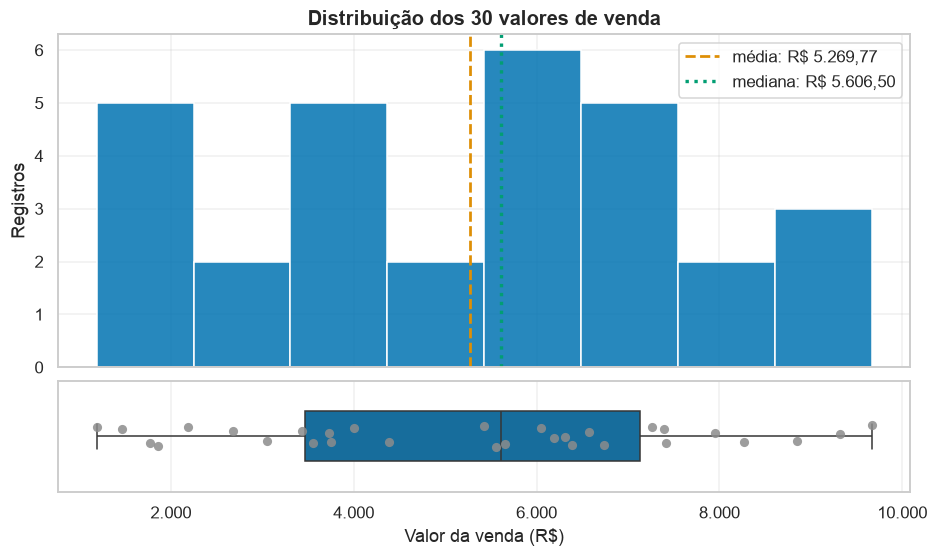

In [32]:
vendas = df_vendas["Vendas"]
media, mediana = vendas.mean(), vendas.median()

fig, (topo, base) = plt.subplots(
    2, 1, figsize=(10, 5.4), sharex=True,
    gridspec_kw={"height_ratios": [3, 1], "hspace": 0.06},
)

sns.histplot(vendas, bins=8, color=AZUL, edgecolor="white", alpha=0.85, ax=topo)
topo.axvline(media, color=LARANJA, linestyle="--", linewidth=1.8,
             label=f"média: {reais(media, 2)}")
topo.axvline(mediana, color=VERDE, linestyle=":", linewidth=2.2,
             label=f"mediana: {reais(mediana, 2)}")
topo.set_title("Distribuição dos 30 valores de venda")
topo.set_ylabel("Registros")
topo.set_xlabel("")
topo.legend(frameon=True)

sns.boxplot(x=vendas, color=AZUL, width=0.45, fliersize=0, ax=base)
sns.stripplot(x=vendas, color=CINZA, size=6, alpha=0.85, jitter=0.10, ax=base)
base.set_xlabel("Valor da venda (R$)")
base.set_ylabel("")
base.xaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"{v:,.0f}".replace(",", ".")))

plt.tight_layout()
plt.show()

In [33]:
resumo = vendas.describe()[["min", "25%", "50%", "75%", "max"]]
for rotulo, valor in resumo.items():
    print(f"{rotulo:>5} {reais(valor, 2):>14}")

print(f"\nMédia {reais(media, 2)} e mediana {reais(mediana, 2)} "
      f"diferem em {abs(media - mediana) / mediana:.1%}: a distribuição é praticamente simétrica.")
print(f"Amplitude: {reais(vendas.max() - vendas.min())}, sobre um intervalo sorteado "
      f"de R$ 1.000 a R$ 9.999.")
print(f"Valores fora dos limites do boxplot (outliers): "
      f"{((vendas < resumo['25%'] - 1.5 * (resumo['75%'] - resumo['25%'])) | (vendas > resumo['75%'] + 1.5 * (resumo['75%'] - resumo['25%']))).sum()}")

  min    R$ 1.189,00
  25%    R$ 3.464,25
  50%    R$ 5.606,50
  75%    R$ 7.132,25
  max    R$ 9.666,00

Média R$ 5.269,77 e mediana R$ 5.606,50 diferem em 6.0%: a distribuição é praticamente simétrica.
Amplitude: R$ 8.477, sobre um intervalo sorteado de R$ 1.000 a R$ 9.999.
Valores fora dos limites do boxplot (outliers): 0


**Leitura.** Média e mediana quase coincidem e não há nenhum ponto fora dos limites do
diagrama de caixa. Isso é o retrato de uma distribuição **uniforme**, que é exatamente
o que `np.random.randint(1000, 10000, 30)` produz: todo valor do intervalo tem a mesma
chance de sair.

O contraste com dados reais é o ponto útil aqui. Faturamento de verdade quase nunca se
parece com isso: costuma ser assimétrico à direita, com muitos valores baixos, poucos
valores altos e uma média bem acima da mediana. As irregularidades do histograma acima
são só ruído amostral de 30 observações espalhadas em 8 faixas, e não teriam
interpretação nem se os dados fossem reais.

---

# 5. 📋 Conclusões

## Respostas do Desafio 1

| Pergunta | Resposta | Ressalva |
|---|---|---|
| 1. Vendedor com maior número de vendas | **Ana** em volume: 12 vendas, R$ 66.264 e 156 unidades. **Pedro** em ticket médio: R$ 5.677,56 | Ana tem 12 registros contra 9, por construção da lista, e não por desempenho |
| 2. Região com maior faturamento total | **Sudeste**, R$ 35.457 (24,3% do total) | Vantagem de 0,12% sobre o Norte; a simulação de 10 mil sorteios mostra que é ruído |
| 3. Produto mais vendido em quantidade | **Notebook**, 70 unidades | Não é o que mais fatura, porque valor e quantidade são independentes nestes dados |
| 4. Média de vendas por vendedor | Pedro R$ 5.677,56, Ana R$ 5.522,00, João R$ 4.525,67 | Média geral de R$ 5.269,77; com 9 a 12 observações, as diferenças são compatíveis com acaso |

## O que a limpeza do Desafio 2 produziu

De 12 registros para 9, com 8 tipos de defeito corrigidos. As duas decisões que mais
mudaram o resultado: **padronizar o texto antes de deduplicar**, sem o que a segunda
duplicata teria passado despercebida, e **converter as datas formato a formato**, sem
o que uma data teria sido lida como 3 de fevereiro em vez de 2 de março, em silêncio e
sem erro nenhum.

## O que os gráficos do Desafio 3 mostraram

O primeiro gráfico transforma em imagem a inversão do pódio conforme a métrica. O
segundo expõe as combinações que não existem, e com isso a estrutura artificial do
conjunto. O terceiro mostra uma distribuição uniforme e simétrica, que é a assinatura
de `np.random.randint` e o oposto do que se espera de faturamento real.

## Limitações

1. **Os dados de vendas são sintéticos.** Nada aqui descreve vendedores, produtos ou
   regiões de verdade. Toda conclusão vale sobre o conjunto gerado, e não sobre o
   mundo.
2. **`Produto` e `Regiao` são redundantes.** Não há como separar o efeito de uma do
   efeito da outra, porque nos dados elas são a mesma coluna.
3. **A amostra é minúscula.** Trinta registros no total, 6 por região e de 9 a 12 por
   vendedor. Nesse tamanho, quase nenhuma diferença observada sobrevive a um segundo
   sorteio, como a simulação da seção 2.4 demonstrou.
4. **O cadastro do Desafio 2 também é inventado**, construído para exibir defeitos
   específicos. Os defeitos são realistas; as pessoas e os valores, não.
5. **Os valores preenchidos não são medições.** A mediana usada nas idades ausentes e
   o rótulo `"Não informado"` nas cidades são marcas de que ali falta dado, e devem
   continuar sendo tratados assim em qualquer análise posterior.

---

**Ambiente:** Python 3.12 com numpy, pandas, matplotlib e seaborn.
**Reprodutibilidade:** `np.random.seed(42)` para os dados da aula, semente 0 na
simulação e data de referência fixa nas colunas derivadas. Executar o notebook do
início ao fim reproduz todos os números deste documento.